*  Record two different sounds  
*  Compute their spectral characteristics (spectrum, MFCC, GFCC)  
*  Build a spectrogram  
*  Analyze their similarities and differences  

In [1]:
# Start

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sounddevice as sd
from scipy.fft import fft, fftfreq
from scipy.io import wavfile
from scipy import signal
from scipy.fft import fft, fftfreq, rfft, rfftfreq, irfft
import librosa
import librosa.display
from python_speech_features import mfcc, logfbank
from scipy.fftpack import dct


f1 = 'data/Alesis-Fusion-Nylon-String-Guitar-C4.wav'
f2 = 'data/Ensoniq-ESQ-1-Piano-C3.wav'

samplerate1, data1 = wavfile.read(f1)
samplerate2, data2 = wavfile.read(f2)

print('Guitar — Sampling Rate:', samplerate1)
print('Guitar — Audio Shape:', np.shape(data1))

print('Piano — Sampling Rate:', samplerate2)
print('Piano — Audio Shape:', np.shape(data2))

Guitar — Sampling Rate: 44100
Guitar — Audio Shape: (97374, 2)
Piano — Sampling Rate: 44100
Piano — Audio Shape: (123880, 2)


C:\Users\zuben\AppData\Local\Temp\ipykernel_26400\212087301.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate1, data1 = wavfile.read(f1)
C:\Users\zuben\AppData\Local\Temp\ipykernel_26400\212087301.py:19: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate2, data2 = wavfile.read(f2)


In [3]:
#конвертируем в моно
if len(data1.shape) > 1:
    data1 = data1[:, 0]
if len(data2.shape) > 1:
    data2 = data2[:, 0]


duration1 = len(data1) / samplerate1
duration2 = len(data2) / samplerate2

time1 = np.arange(len(data1)) / samplerate1  
time2 = np.arange(len(data2)) / samplerate2  

print('time1 shape:', time1.shape, 'data1 shape:', data1.shape)
print('time2 shape:', time2.shape, 'data2 shape:', data2.shape)

time1 shape: (97374,) data1 shape: (97374,)
time2 shape: (123880,) data2 shape: (123880,)


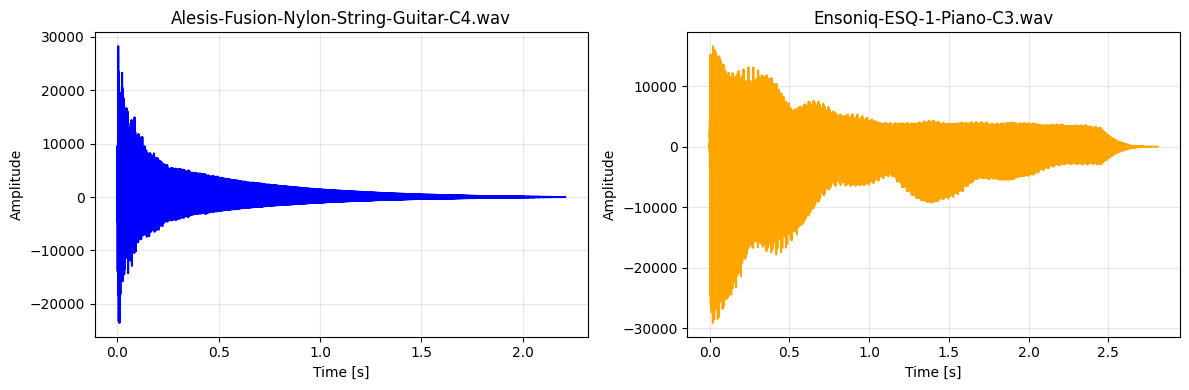

In [5]:
#Графики
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(time1, data1, color='blue')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Alesis-Fusion-Nylon-String-Guitar-C4.wav')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(time2, data2, color='orange')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Ensoniq-ESQ-1-Piano-C3.wav')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

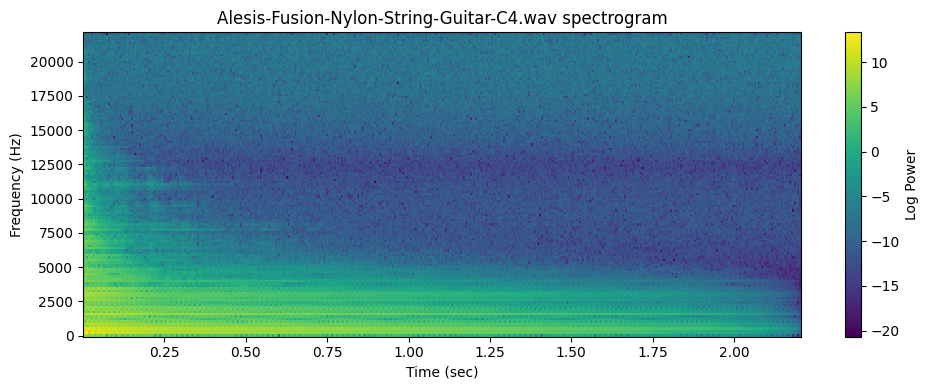

In [7]:
#Спектр первого звука
adata1 = data1
s1 = samplerate1
fr1, tm1, spgram1 = signal.spectrogram(adata1, s1)
lspg1 = np.log(spgram1 + 1e-10)

plt.figure(figsize=(10, 4))
plt.pcolormesh(tm1, fr1, lspg1, shading='auto')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (sec)')
plt.title('Alesis-Fusion-Nylon-String-Guitar-C4.wav spectrogram')
plt.colorbar(label='Log Power')
plt.tight_layout()
plt.show()

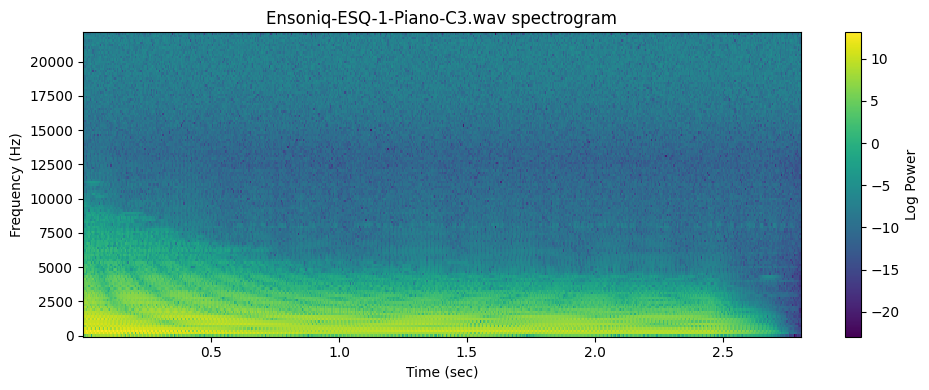

In [8]:
#Спектр второго звука
adata2 = data2
s2 = samplerate2
fr2, tm2, spgram2 = signal.spectrogram(adata2, s2)
lspg2 = np.log(spgram2 + 1e-10)

plt.figure(figsize=(10, 4))
plt.pcolormesh(tm2, fr2, lspg2, shading='auto')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (sec)')
plt.title('Ensoniq-ESQ-1-Piano-C3.wav spectrogram')
plt.colorbar(label='Log Power')
plt.tight_layout()
plt.show()

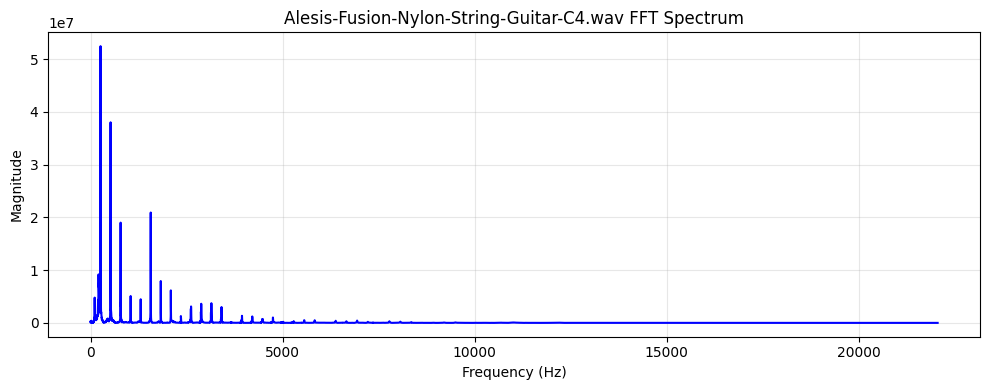

In [9]:
N1 = len(data1)
yf1 = rfft(data1)
xf1 = rfftfreq(N1, 1 / samplerate1)

plt.figure(figsize=(10, 4))
plt.plot(xf1, np.abs(yf1), color='blue')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Alesis-Fusion-Nylon-String-Guitar-C4.wav FFT Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

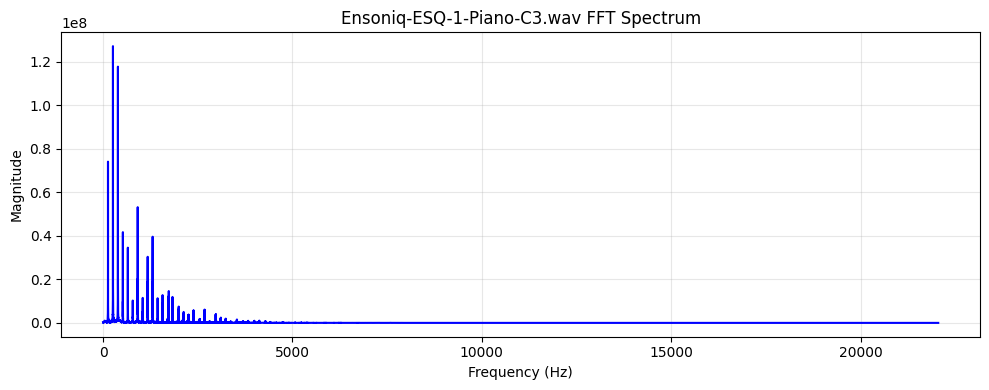

In [10]:
N2 = len(data2)
yf2 = rfft(data2)
xf2 = rfftfreq(N2, 1 / samplerate2)

plt.figure(figsize=(10, 4))
plt.plot(xf2, np.abs(yf2), color='blue')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Ensoniq-ESQ-1-Piano-C3.wav FFT Spectrum')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

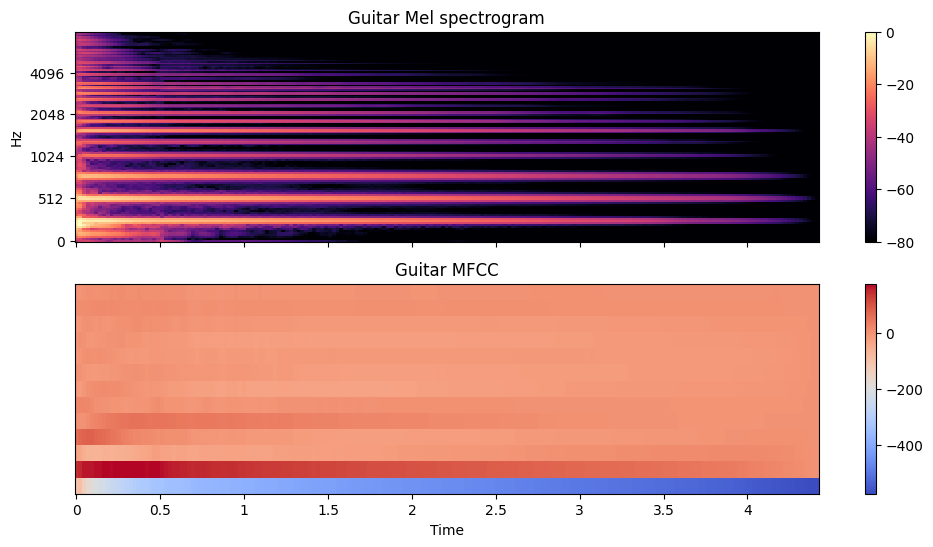

In [12]:
y1, sr1 = librosa.load(f1, sr=None)
mfccs1 = librosa.feature.mfcc(y=y1, sr=sr1, n_mfcc=13)
S1 = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128, fmax=8000)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(12, 6))
img1 = librosa.display.specshow(librosa.power_to_db(S1, ref=np.max),
                                x_axis='time', y_axis='mel', fmax=8000,
                                ax=ax[0])
fig.colorbar(img1, ax=[ax[0]])
ax[0].set(title='Guitar Mel spectrogram')
ax[0].label_outer()

img2 = librosa.display.specshow(mfccs1, x_axis='time', ax=ax[1])
fig.colorbar(img2, ax=[ax[1]])
ax[1].set(title='Guitar MFCC')
plt.show()

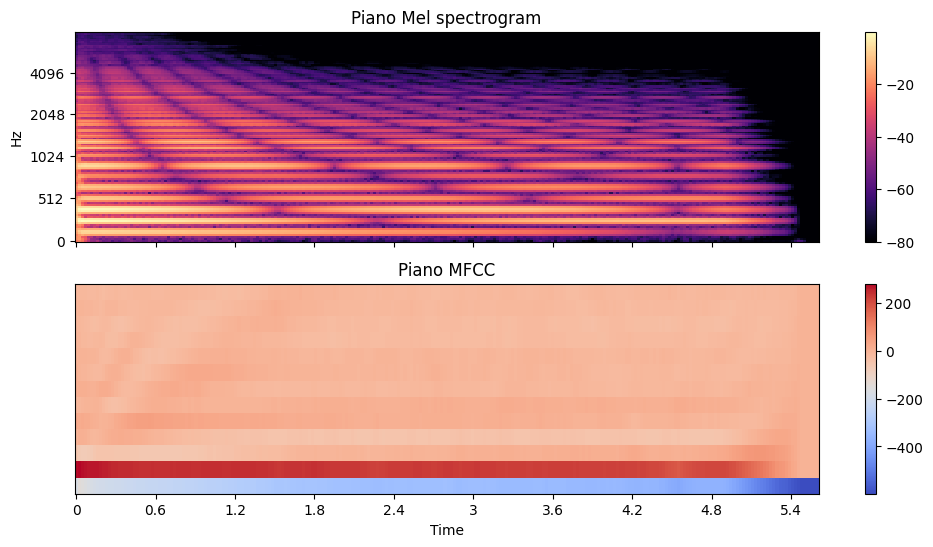

In [13]:
y2, sr2 = librosa.load(f2, sr=None)
mfccs2 = librosa.feature.mfcc(y=y2, sr=sr2, n_mfcc=13)
S2 = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128, fmax=8000)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(12, 6))
img3 = librosa.display.specshow(librosa.power_to_db(S2, ref=np.max),
                                x_axis='time', y_axis='mel', fmax=8000,
                                ax=ax[0])
fig.colorbar(img3, ax=[ax[0]])
ax[0].set(title='Piano Mel spectrogram')
ax[0].label_outer()
img4 = librosa.display.specshow(mfccs2, x_axis='time', ax=ax[1])
fig.colorbar(img4, ax=[ax[1]])
ax[1].set(title='Piano MFCC')
plt.show()

In [ ]:
# Расчёт MFCC

In [14]:
(rate1, sig1) = wavfile.read(f1)
if len(sig1.shape) > 1:
    sig1 = sig1[:, 0]
mfcc_feat1 = mfcc(sig1, rate1, numcep=13)
fbank_feat1 = logfbank(sig1, rate1, nfilt=40)

print('Guitar MFCC shape:', mfcc_feat1.shape)
print('Guitar Filterbank sample:\n', fbank_feat1[1:3, :])


# %%
# Второй звук
(rate2, sig2) = wavfile.read(f2)
if len(sig2.shape) > 1:
    sig2 = sig2[:, 0]
mfcc_feat2 = mfcc(sig2, rate2, numcep=13)
fbank_feat2 = logfbank(sig2, rate2, nfilt=40)

print('Piano MFCC shape:', mfcc_feat2.shape)
print('Piano Filterbank sample:\n', fbank_feat2[1:3, :])

C:\Users\zuben\AppData\Local\Temp\ipykernel_26400\2112618373.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  (rate1, sig1) = wavfile.read(f1)
C:\Users\zuben\AppData\Local\Temp\ipykernel_26400\2112618373.py:13: WavFileWarning: Chunk (non-data) not understood, skipping it.
  (rate2, sig2) = wavfile.read(f2)


Guitar MFCC shape: (220, 13)
Guitar Filterbank sample:
 [[13.93509611 13.85775222 16.27720877 16.46187845 13.80122529 13.22768885
  17.02881786 13.66233342 16.24462319 12.55246533 14.0195323  13.22987387
  13.18364227 17.22522211 15.81163627 16.51760904 16.08293802 16.17059823
  17.37090017 18.03720919 17.4343786  15.963349   16.75438675 16.90035177
  15.60560798 16.3017226  16.15482852 16.81807584 16.52640081 16.52858544
  15.54098824 14.78518313 14.01286847 13.86439311 13.3349894  12.22240232
  11.58088048  9.25482801  7.98367193  8.1137688 ]
 [ 9.65600716 12.25693337 14.92174327 16.6288183  12.6500318  11.58089823
  16.89725608 12.20652179 16.23655487 12.9046868  14.23505303 13.61838293
  13.78961085 17.31285791 15.0629421  16.23947511 15.98959119 16.71034213
  17.12635152 17.74908138 17.29694053 16.09581842 16.74743343 16.66675276
  15.1774757  16.21534072 15.97041775 16.38840375 15.8428301  15.7339784
  14.05933787 13.39617307 12.9384671  11.98427005 12.01047951 10.70549056
  10.4

In [15]:
def compute_gfcc_framed(audio, sr, numcep=22, nfilt=32, winlen=0.025, winstep=0.01):
 
    win_length = int(winlen * sr)
    hop_length = int(winstep * sr)
    

    audio = np.append(audio[0], audio[1:] - 0.97 * audio[:-1])
    
    frames = []
    for i in range(0, len(audio) - win_length, hop_length):
        frame = audio[i:i+win_length] * np.hamming(win_length)
        frames.append(frame)
    frames = np.array(frames)
    
    spectrum = np.abs(rfft(frames, axis=1)) ** 2
    freqs = rfftfreq(win_length, 1/sr)
    
    def erb(f): return 21.366 * np.log(1 + f / 700)
    def inv_erb(z): return 700 * (np.exp(z / 21.366) - 1)
    
    low_freq, high_freq = 0, sr / 2
    erb_min, erb_max = erb(low_freq), erb(high_freq)
    erb_centers = np.linspace(erb_min, erb_max, nfilt)
    center_freqs = inv_erb(erb_centers)
    
    filters = np.zeros((nfilt, len(freqs)))
    for i in range(nfilt):
        fc = center_freqs[i]
        bw = 24.7 * (4.37 * fc / 1000 + 1)
        for j, f in enumerate(freqs):
            if abs(f - fc) < bw:
                filters[i, j] = max(0, 1 - abs(f - fc) / bw)

    energies = np.dot(filters, spectrum.T).T + 1e-10
    log_energies = np.log(energies)
    gfcc = dct(log_energies, type=2, norm='ortho', axis=1)[:, :numcep]
    
    return gfcc

gfcc1_framed = compute_gfcc_framed(data1, samplerate1)
gfcc2_framed = compute_gfcc_framed(data2, samplerate2)

print('Guitar GFCC:', gfcc1_framed.shape)
print('Piano GFCC:', gfcc2_framed.shape)

Guitar GFCC: (219, 22)
Piano GFCC: (279, 22)


In [ ]:
# Сравнение звуков

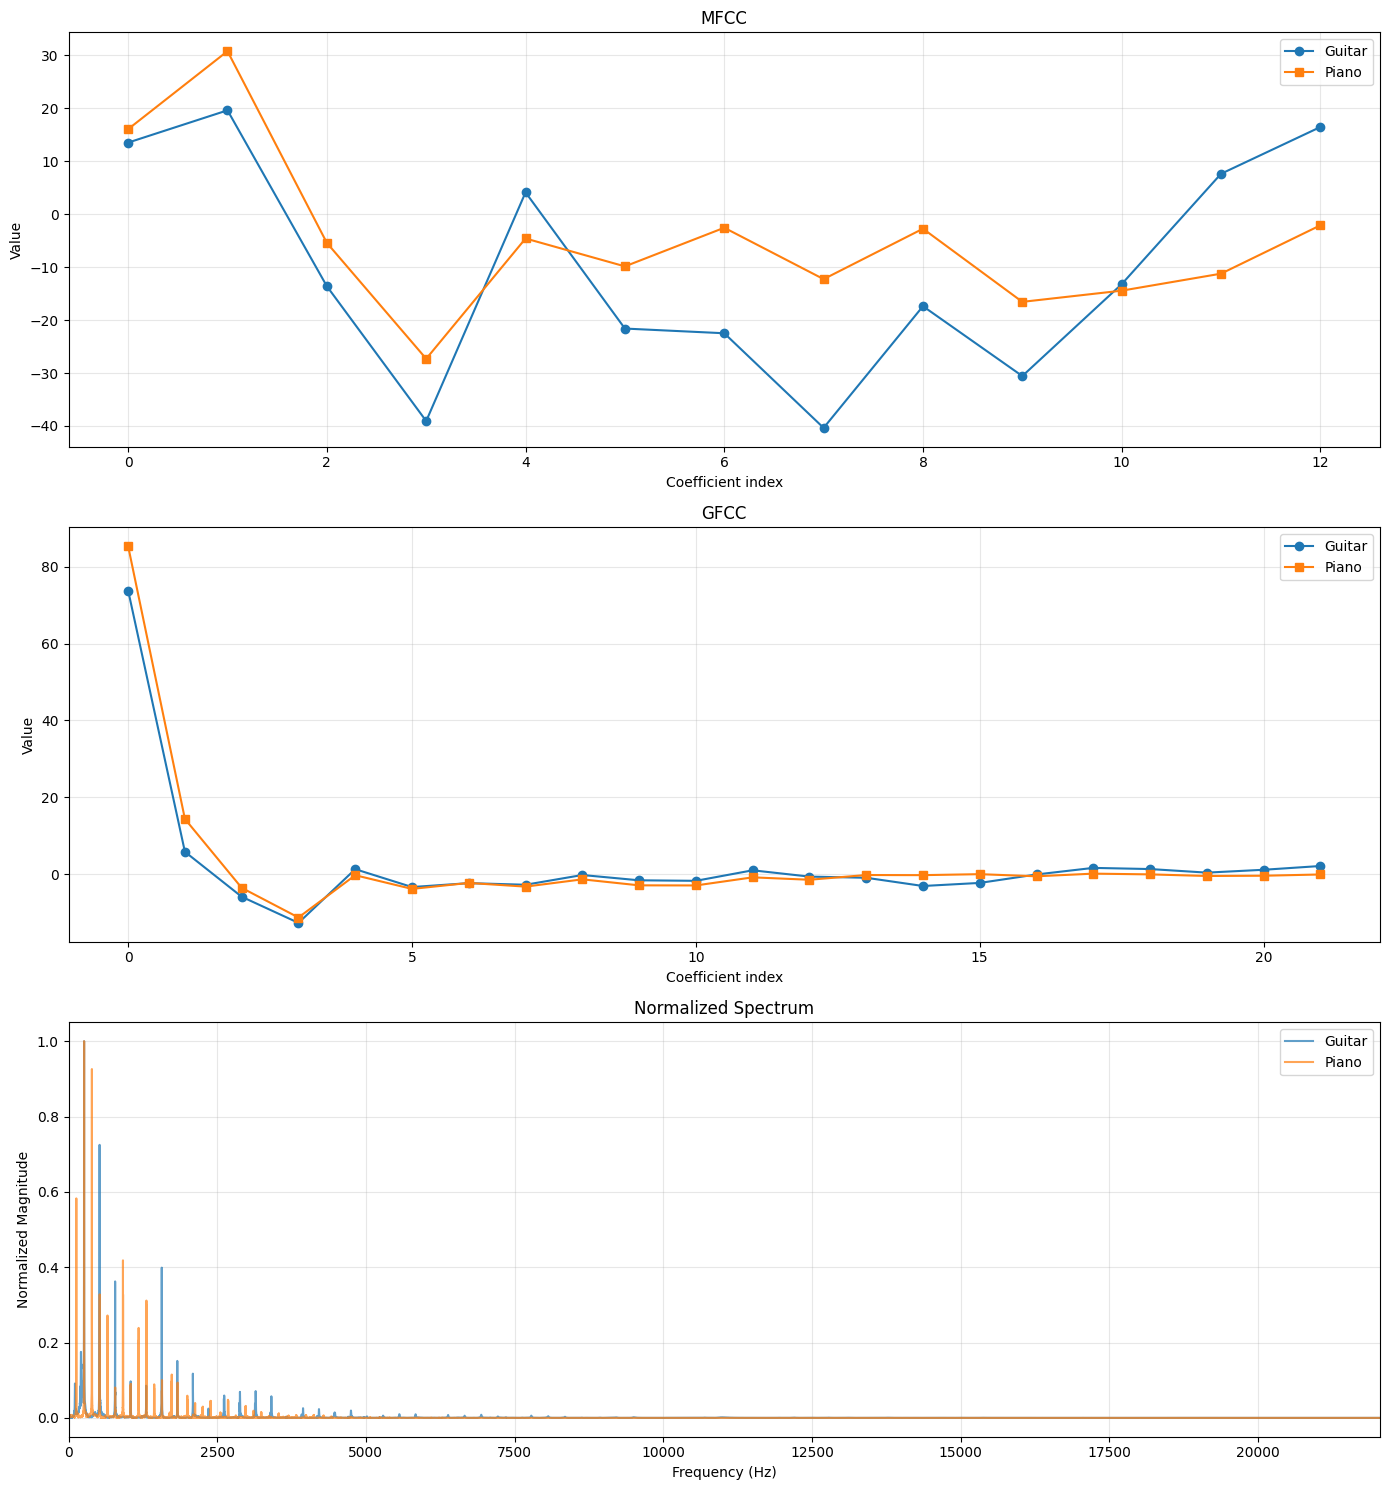

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

axes[0].plot(np.mean(mfcc_feat1, axis=0), label='Guitar', marker='o')
axes[0].plot(np.mean(mfcc_feat2, axis=0), label='Piano', marker='s')
axes[0].set_title('MFCC')
axes[0].set_xlabel('Coefficient index')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(np.mean(gfcc1_framed, axis=0), label='Guitar', marker='o')
axes[1].plot(np.mean(gfcc2_framed, axis=0), label='Piano', marker='s')
axes[1].set_title('GFCC')
axes[1].set_xlabel('Coefficient index')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(xf1, np.abs(yf1) / (np.max(np.abs(yf1)) + 1e-10),
             label='Guitar', alpha=0.7)
axes[2].plot(xf2, np.abs(yf2) / (np.max(np.abs(yf2)) + 1e-10),
             label='Piano', alpha=0.7)
axes[2].set_title('Normalized Spectrum')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Normalized Magnitude')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_xlim(0, min(samplerate1, samplerate2) / 2)

plt.tight_layout()
plt.show()

In [35]:
# Создаём общую сетку частот от 0 до Найквиста
fmin = max(xf1.min(), xf2.min())
fmax = min(xf1.max(), xf2.max())
common_freq = np.linspace(fmin, fmax, 1000)

# Интерполируем оба спектра на эту сетку
spec1_interp = np.interp(common_freq, xf1, np.abs(yf1))
spec2_interp = np.interp(common_freq, xf2, np.abs(yf2))

# Считаем корреляцию
corr = np.corrcoef(np.log(spec1_interp + 1e-10),
                   np.log(spec2_interp + 1e-10))[0, 1]
print(f'Корреляция спектров: {corr:.3f}')

Корреляция спектров: 0.672
